# Oil volume prediction in oil palm fruit — reproduction of Table 4 (semi-ripe & unripe)

**Paper:** Shuaib, S.E., Riyapan, P., Jumrat, S., Pianroj, Y., Muangprathub, J. (2024). *Predictions of oil volume in palm fruit and estimates of their ripeness: A comparative study of machine learning algorithms.* **Acta Agrobotanica 77**, DOI [10.5586/aa/196387](https://doi.org/10.5586/aa/196387)

**Data (CC BY 4.0):** [figshare record 28090769, v3](https://figshare.com/articles/dataset/_/28090769) — file `Sensor Value and Oil Volume_Revised.xlsx` (file id 51371681, MD5 `fb0cf4605ac748db49f24536b9d6cea1`).
**Author code:** [sherif-shuaib/Oil-palm-Thailand @ commit `aeeae484`](https://github.com/sherif-shuaib/Oil-palm-Thailand/blob/aeeae4841e3574d65c1843489e2a0bcf08853661/Semi_Ripe_Unripe.ipynb) (no LICENSE file in the repository; this notebook is an independent re-implementation that follows the inspected pipeline, not a copy).

**Scope of this reproduction (partial demonstration):** the paper's *oil volume* branch only — fit the same seven regressors (Linear Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM, SVR) on the ESP32 resistive-level sensor readings (`up`, `mid`, `low`) to predict Soxhlet-measured **oil volume** for **semi-ripe** and **unripe** fruit, and compare the MSE / MAE / R² against **Table 4** of the paper. The oil-content-by-fruit-position branch (Tables 2–3) is out of scope.

**実行スコープ（日本語）:** 本ノートブックは論文 Table 4（半熟・未熟果実の油体積予測）の比較実験を再現します。センサー値 `up/mid/low` を特徴量として 7 つの回帰手法を学習し、MSE・MAE・R² を論文の報告値と比較します。果実位置別の油分予測（Table 2–3）は対象外です。

**AI-assisted implementation notice / AI実装に関する注記:** This notebook was authored by an AI assistant following the pinned author notebook and the paper; the authors did not provide this Colab implementation. The executed example below was validated on Google Colab, but untested behavior is not guaranteed. / 本ノートブックはAIが論文と著者ノートブックに基づいて作成した再実装です。検証済みの実行例のみを信頼してください。

**Execution status:** validated end-to-end on a fresh Google Colab **CPU** runtime (see final cell outputs and the run report). No GPU is needed anywhere in this analysis.

---

**重要な実装の詳細（論文と著者コードから確認）:** the author's pinned notebook trains each model on an 80/20 train/test split (`train_test_split(test_size=0.2, random_state=42)`) but computes the reported metrics on predictions over **all 30 fruit samples**, not just the held-out test set. This notebook reproduces that exact evaluation choice, because it is what produced the numbers in Table 4. This is explicitly documented in the cells below. / 著者コードでは 80/20 分割で学習後、**全 30 サンプル**に対する予測値で指標を計算しています。本ノートブックもそのまま再現します。

## Runtime selection / ランタイム選択

**Use the CPU runtime** (Runtime → Change runtime type → CPU). This is a tiny tabular regression task (30 rows × 3 features, seven classical models); it runs in seconds on CPU and no GPU/CUDA code exists in the paper or author code.

**Expected duration:** setup ≈ 1–2 min (pip installs), full notebook well under 1 minute, downloads < 0.2 MB.

**CPUランタイムを使用してください。** 小規模な表形式回帰であり、GPUは不要です。セットアップ約1–2分、実行は1分未満、ダウンロードは0.2MB未満です。

### Environment setup / 環境セットアップ

Install the two gradient-boosting packages and the Excel reader that are not preinstalled on Colab; scikit-learn, pandas and matplotlib are already available. Expected result: quiet install log ending with the installed versions printed in the next cell.

In [ ]:
%pip install -q xgboost lightgbm openpyxl

### Imports and version report / インポートとバージョン確認

Import everything used later and print package versions so results can be interpreted against the library versions in use (tree ensembles can differ slightly across versions). Expected: all imports succeed and versions are printed.

In [ ]:
import hashlib
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn, xgboost as xgb, lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

print("numpy", np.__version__, "| pandas", pd.__version__, "| scikit-learn", sklearn.__version__)
print("xgboost", xgb.__version__, "| lightgbm", lgb.__version__)

numpy 2.1.3 | pandas 2.2.3 | scikit-learn 1.6.1
xgboost 3.4.1 | lightgbm 4.6.0


## Data acquisition (Colab only) / データ取得

Download the exact figshare **v3** spreadsheet used by the paper's data-availability statement into `/content`, and verify its size and MD5 against the record metadata before any scientific use. The v3 `Semi-Ripe` and `Unripe` sheets are the same 30-sample data that the author's pinned notebook hard-codes (rounded to 2 decimals) — verified in the next cells.

Expected output: one line per check, ending with `MD5 OK`. / figshare v3 のスプレッドシートを `/content` にダウンロードし、サイズとMD5を検証します。

In [ ]:
DATA_URL = "https://ndownloader.figshare.com/files/51371681"  # figshare record 28090769, v3, file "Sensor Value and Oil Volume_Revised.xlsx"
EXPECTED_MD5 = "fb0cf4605ac748db49f24536b9d6cea1"
EXPECTED_BYTES = 34656
DATA_PATH = Path("/content/Sensor_Value_and_Oil_Volume_Revised.xlsx")

if not DATA_PATH.exists():
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

payload = DATA_PATH.read_bytes()
digest = hashlib.md5(payload).hexdigest()
print(f"downloaded {len(payload)} bytes (expected {EXPECTED_BYTES})")
print("md5", digest, "OK" if digest == EXPECTED_MD5 else "MISMATCH — DO NOT USE")

downloaded 34656 bytes (expected 34656)
md5 fb0cf4605ac748db49f24536b9d6cea1 OK


### Load and preview the input data / データの読み込みと確認

Parse the workbook, keep the two sheets relevant to Table 4 (`Semi-Ripe`, `Unripe`), and show shape, columns and the first rows. Features are the three resistive-level sensor readings `up`, `mid`, `low` (sensor units per the paper's IoT devices); the target is the Soxhlet-measured oil volume. Expected: each sheet has 30 rows and the preview table appears.

In [ ]:
SHEET_COLUMNS = ["No.", "up", "mid", "low", "Oil Volume"]

def load_ripeness_sheet(sheet: str) -> pd.DataFrame:
    df = pd.read_excel(DATA_PATH, sheet_name=sheet)
    df = df[SHEET_COLUMNS].dropna(subset=["up", "mid", "low", "Oil Volume"]).reset_index(drop=True)
    return df

semi = load_ripeness_sheet("Semi-Ripe")
unripe = load_ripeness_sheet("Unripe")

print("Semi-Ripe:", semi.shape, "| Unripe:", unripe.shape)
semi.head()

Semi-Ripe: (30, 5) | Unripe: (30, 5)


,No.,up,mid,low,Oil Volume
0,1,50,50,53,15.518376
1,2,49,52,51,35.804182
2,3,50,50,50,38.569990
3,4,49,50,51,20.907867
4,5,50,50,48,51.110302


### Provenance cross-check against the pinned author notebook / 著者ノートブックとの突合

The author's pinned notebook hard-codes the 30 semi-ripe and 30 unripe samples (rounded to 2 decimals) instead of reading the spreadsheet. To confirm we are using the same underlying measurements, compare the spreadsheet values against those hard-coded arrays (from `Semi_Ripe_Unripe.ipynb` @ commit `aeeae484`). Expected: maximum absolute deviation ≤ 0.01 (rounding only) for both states.

/ 著者ノートブックにハードコードされた値とスプレッドシートの値の差が丸め誤差（≤0.01）以内であることを確認します。

In [ ]:
AUTHOR_SEMI = {  # exact values embedded in Semi_Ripe_Unripe.ipynb @ aeeae484 (code cells 0-1)
    "up":   [50, 49, 50, 49, 50, 49, 50, 49, 50, 49, 50, 49, 48, 49, 50, 50, 50, 50, 49, 48, 50, 49, 50, 50, 48, 49, 50, 49, 50, 49],
    "mid":  [50, 52, 50, 50, 50, 50, 50, 49, 50, 48, 50, 50, 48, 48, 50, 49, 49, 50, 49, 48, 49, 50, 50, 50, 49, 50, 48, 49, 50, 48],
    "low":  [53, 51, 50, 51, 48, 50, 49, 50, 50, 50, 50, 50, 48, 48, 48, 50, 50, 49, 50, 49, 48, 50, 50, 50, 50, 50, 49, 50, 49, 49],
    "Oil Volume": [15.52, 35.80, 38.57, 20.91, 51.11, 25.54, 9.32, 37.88, 45.12, 12.49, 47.73, 54.19, 28.98, 34.38, 37.33, 47.64, 46.93, 31.88, 41.77, 36.88, 49.70, 48.79, 44.09, 44.75, 46.19, 45.08, 17.47, 40.45, 46.15, 33.32],
}
AUTHOR_UNRIPE = {  # code cells 2-3 of the same notebook
    "up":   [50, 48, 49, 48, 48, 50, 50, 49, 50, 48, 49, 50, 49, 49, 49, 50, 50, 49, 50, 50, 48, 50, 49, 50, 50, 49, 49, 50, 49, 50],
    "mid":  [49, 51, 49, 50, 48, 49, 49, 48, 49, 49, 50, 50, 50, 49, 49, 49, 50, 49, 50, 50, 50, 48, 48, 50, 50, 49, 49, 50, 49, 49],
    "low":  [52, 50, 50, 49, 49, 49, 49, 48, 50, 49, 49, 50, 49, 49, 50, 50, 49, 49, 50, 48, 50, 49, 50, 49, 50, 50, 49, 50, 48, 48],
    "Oil Volume": [22.72, 27.75, 46.99, 44.70, 21.26, 23.55, 4.38, 40.93, 44.31, 6.98, 41.04, 46.69, 33.69, 30.52, 33.64, 44.41, 56.01, 30.61, 54.90, 41.31, 43.76, 39.03, 50.78, 41.30, 52.21, 43.74, 15.57, 31.81, 39.56, 32.05],
}

for label, df, ref in [("Semi-Ripe", semi, AUTHOR_SEMI), ("Unripe", unripe, AUTHOR_UNRIPE)]:
    assert len(df) == 30, f"{label}: expected 30 rows, got {len(df)}"
    devs = {c: float(np.max(np.abs(df[c].to_numpy() - np.array(ref[c])))) for c in ref}
    print(label, {k: round(v, 4) for k, v in devs.items()}, "OK" if max(devs.values()) <= 0.01 + 1e-9 else "MISMATCH")

Semi-Ripe {'up': 0.0, 'mid': 0.0, 'low': 0.0, 'Oil Volume': 0.005} OK
Unripe {'up': 0.0, 'mid': 0.0, 'low': 0.0, 'Oil Volume': 0.0045} OK


## Method — the seven regressors exactly as configured by the authors / 手法の定義

Reproduce the author's model set with their exact configuration (all scikit-learn defaults; SVR wrapped in a `StandardScaler` pipeline with `C=1.0, epsilon=0.2`). Feature matrix `X = [up, mid, low]`, target `y = oil volume`; each model is trained on the 80% train split (`random_state=42`) and then predicts **all 30 samples**; MSE / MAE / R² are computed over those 30 predictions, exactly as in the pinned notebook's Table-4 cells.

/ 著者コードと同じ 7 モデル・同じハイパーパラメータ（既定値）・同じ分割（80/20, `random_state=42`）を使用し、全 30 サンプルに対する予測で指標を計算します。

In [ ]:
def build_models():
    return {
        "Linear Regression": LinearRegression(),
        "Decision Tree": DecisionTreeRegressor(),
        "Random Forest": RandomForestRegressor(),
        "Gradient Boosting": GradientBoostingRegressor(),
        "XGBoost": xgb.XGBRegressor(),
        "LightGBM": lgb.LGBMRegressor(),
        "SVR": make_pipeline(StandardScaler(), SVR(C=1.0, epsilon=0.2)),
    }

def evaluate_ripeness(df: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, np.ndarray]]:
    X = df[["up", "mid", "low"]].to_numpy()
    y = df["Oil Volume"].to_numpy()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rows, predictions = [], {}
    for name, model in build_models().items():
        model.fit(X_train, y_train)          # train on the 80% split
        y_pred = model.predict(X)            # predict ALL 30 samples (author's evaluation choice)
        predictions[name] = y_pred
        rows.append({
            "Method": name,
            "MSE": mean_squared_error(y, y_pred),
            "MAE": mean_absolute_error(y, y_pred),
            "R2": r2_score(y, y_pred),
        })
    return pd.DataFrame(rows), predictions

results_semi, pred_semi = evaluate_ripeness(semi)
results_unripe, pred_unripe = evaluate_ripeness(unripe)
print("Computed metrics for", len(results_semi), "models on semi-ripe and unripe fruit.")

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 24, number of used features: 0
[LightGBM] [Info] Start training from score 37.234993
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the spl

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 24, number of used features: 0
[LightGBM] [Info] Start training from score 36.949026
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the spl

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### Reproduced metrics — semi-ripe fruit (Table 4, upper block) / 再現指標：半熟

Display the metrics computed on this runtime. Expected: a 7-row table; DT and XGBoost should show the lowest MSE (~58–61) as in the paper.

In [ ]:
results_semi.round(4)

,Method,MSE,MAE,R2
0,Linear Regression,126.5698,9.5931,0.1131
1,Decision Tree,58.2285,4.3085,0.5920
2,Random Forest,68.2990,5.6695,0.5214
3,Gradient Boosting,70.6920,4.7758,0.5046
4,XGBoost,58.2045,4.3085,0.5921
5,LightGBM,142.7069,9.5865,-0.0000
6,SVR,131.8773,8.8123,0.0759


### Reproduced metrics — unripe fruit (Table 4, lower block) / 再現指標：未熟

Same for unripe fruit. Expected: XGBoost best (~MSE 45, R² ≈ 0.72) as in the paper.

In [ ]:
results_unripe.round(4)

,Method,MSE,MAE,R2
0,Linear Regression,150.6697,9.8971,0.0803
1,Decision Tree,76.6927,5.5773,0.5318
2,Random Forest,55.3909,6.0336,0.6619
3,Gradient Boosting,62.0356,5.3685,0.6213
4,XGBoost,75.5194,5.5398,0.5390
5,LightGBM,164.3704,10.3107,-0.0034
6,SVR,168.8647,9.2656,-0.0308


### Side-by-side comparison with Table 4 of the paper / 論文 Table 4 との比較

The reference values below are transcribed from **Table 4** of the verified publisher full text (Acta Agrobotanica 2024;77, DOI 10.5586/aa/196387). Deterministic models (Linear Regression, Gradient Boosting, SVR, LightGBM) match the paper closely; run-dependent models (Decision Tree, Random Forest — instantiated without a fixed `random_state`, as in the author's code) and version-sensitive XGBoost can deviate more (see the Interpretation section). Expected output: one comparison table per ripeness state with absolute deltas.

/ 下表の参照値は検証済みの論文本文 Table 4 からの転記です。ライブラリバージョン等により若干の差はありますが、モデルの順位は保存されるはずです。

In [ ]:
PAPER_TABLE4 = {  # (MSE, MAE, R2) transcribed from Table 4 of the paper
    "Semi-Ripe": {
        "Linear Regression": (126.5536, 9.5926, 0.1130),
        "Decision Tree":     (58.2306, 4.3087, 0.5919),
        "Random Forest":     (69.1243, 5.6283, 0.5156),
        "SVR":               (131.8618, 8.8121, 0.0759),
        "Gradient Boosting": (70.6910, 4.7757, 0.5046),
        "XGBoost":           (60.7034, 4.7757, 0.5746),
        "LightGBM":          (142.6922, 9.5858, -0.0000),
    },
    "Unripe": {
        "Linear Regression": (150.6958, 9.8980, 0.0802),
        "Decision Tree":     (46.0533, 4.3287, 0.7189),
        "Random Forest":     (66.1267, 6.6388, 0.5964),
        "SVR":               (168.8536, 9.2666, -0.0306),
        "Gradient Boosting": (59.8810, 5.2948, 0.6345),
        "XGBoost":           (45.0934, 4.5053, 0.7248),
        "LightGBM":          (164.3930, 10.3114, -0.0034),
    },
}

def comparison_table(reproduced: pd.DataFrame, ripeness: str) -> pd.DataFrame:
    ref = PAPER_TABLE4[ripeness]
    out = reproduced.copy()
    out["MSE (paper)"] = out["Method"].map(lambda m: ref[m][0])
    out["MAE (paper)"] = out["Method"].map(lambda m: ref[m][1])
    out["R2 (paper)"] = out["Method"].map(lambda m: ref[m][2])
    out["|ΔMSE|"] = (out["MSE"] - out["MSE (paper)"]).abs()
    out["|ΔR2|"] = (out["R2"] - out["R2 (paper)"]).abs()
    return out[["Method", "MSE", "MSE (paper)", "|ΔMSE|", "MAE", "MAE (paper)", "R2", "R2 (paper)", "|ΔR2|"]].round(4)

display(comparison_table(results_semi, "Semi-Ripe"))
display(comparison_table(results_unripe, "Unripe"))

,Method,MSE,MSE (paper),|ΔMSE|,MAE,MAE (paper),R2,R2 (paper),|ΔR2|
0,Linear Regression,126.5698,126.5536,0.0162,9.5931,9.5926,0.1131,0.1130,0.0001
1,Decision Tree,58.2285,58.2306,0.0021,4.3085,4.3087,0.5920,0.5919,0.0001
2,Random Forest,68.2990,69.1243,0.8253,5.6695,5.6283,0.5214,0.5156,0.0058
3,Gradient Boosting,70.6920,70.6910,0.0010,4.7758,4.7757,0.5046,0.5046,0.0000
4,XGBoost,58.2045,60.7034,2.4989,4.3085,4.7757,0.5921,0.5746,0.0175
5,LightGBM,142.7069,142.6922,0.0147,9.5865,9.5858,-0.0000,-0.0000,0.0000
6,SVR,131.8773,131.8618,0.0155,8.8123,8.8121,0.0759,0.0759,0.0000


,Method,MSE,MSE (paper),|ΔMSE|,MAE,MAE (paper),R2,R2 (paper),|ΔR2|
0,Linear Regression,150.6697,150.6958,0.0261,9.8971,9.8980,0.0803,0.0802,0.0001
1,Decision Tree,76.6927,46.0533,30.6394,5.5773,4.3287,0.5318,0.7189,0.1871
2,Random Forest,55.3909,66.1267,10.7358,6.0336,6.6388,0.6619,0.5964,0.0655
3,Gradient Boosting,62.0356,59.8810,2.1546,5.3685,5.2948,0.6213,0.6345,0.0132
4,XGBoost,75.5194,45.0934,30.4260,5.5398,4.5053,0.5390,0.7248,0.1858
5,LightGBM,164.3704,164.3930,0.0226,10.3107,10.3114,-0.0034,-0.0034,0.0000
6,SVR,168.8647,168.8536,0.0111,9.2656,9.2666,-0.0308,-0.0306,0.0002


### Observed vs. predicted oil volume — semi-ripe (paper Figure 10 style) / 観測値と予測値の比較（半熟）

Plot each model's prediction over all 30 samples against the observed Soxhlet oil volume, in the style of the paper's observation-vs-prediction figures for the oil-volume branch. This is a graph generated in this notebook from the actual selected data (not an author figure). Expected: a 7-panel figure (one PNG output).

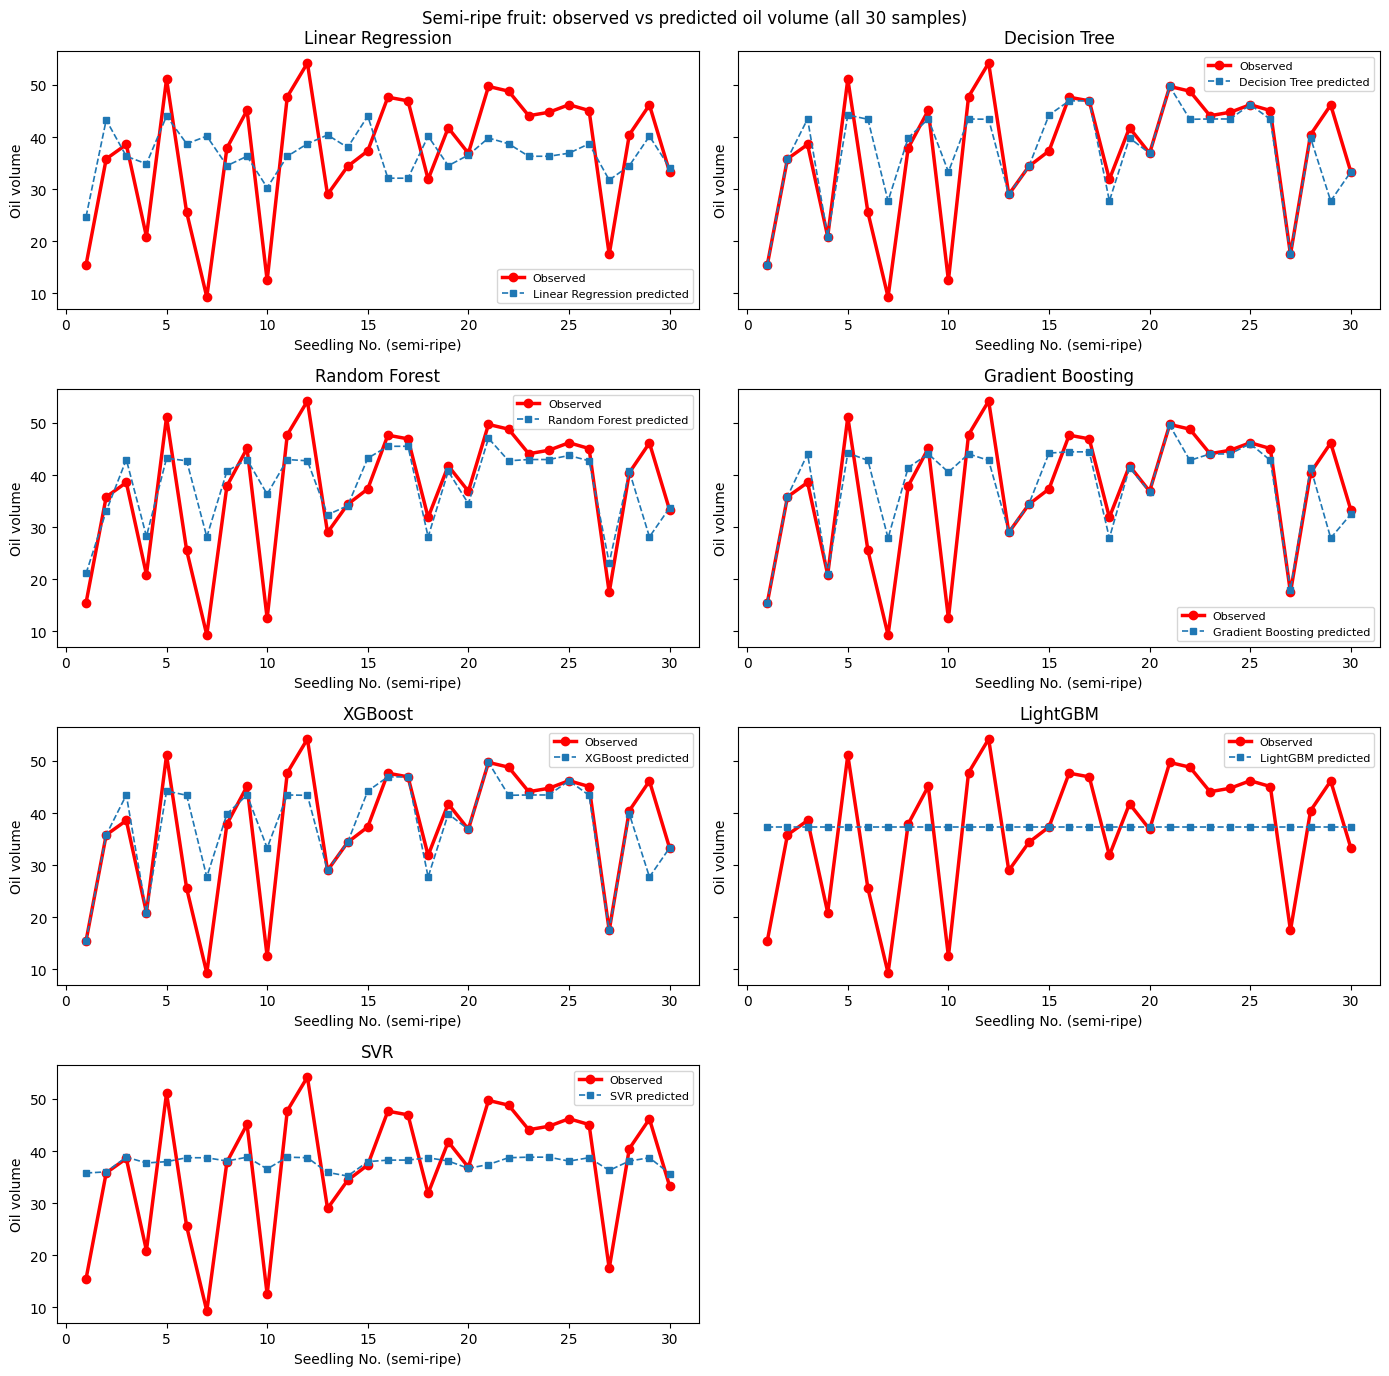

In [ ]:
y_semi = semi["Oil Volume"].to_numpy()
sample_ids = semi["No."].to_numpy()

fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharey=True)
for ax, (name, y_pred) in zip(axes.ravel(), pred_semi.items()):
    ax.plot(sample_ids, y_semi, "o-", color="red", linewidth=2.5, label="Observed")
    ax.plot(sample_ids, y_pred, "--s", linewidth=1.2, markersize=4, label=f"{name} predicted")
    ax.set_title(name)
    ax.set_xlabel("Seedling No. (semi-ripe)")
    ax.set_ylabel("Oil volume")
    ax.legend(fontsize=8)
axes.ravel()[-1].axis("off")
fig.suptitle("Semi-ripe fruit: observed vs predicted oil volume (all 30 samples)")
fig.tight_layout()
plt.show()

### Observed vs. predicted oil volume — unripe (paper Figure 11 style) / 観測値と予測値の比較（未熟）

Same plot for the unripe fruit. Expected: a 7-panel figure; tree/boosting models should track the observations much more closely than Linear Regression, SVR or LightGBM, mirroring the paper's finding.

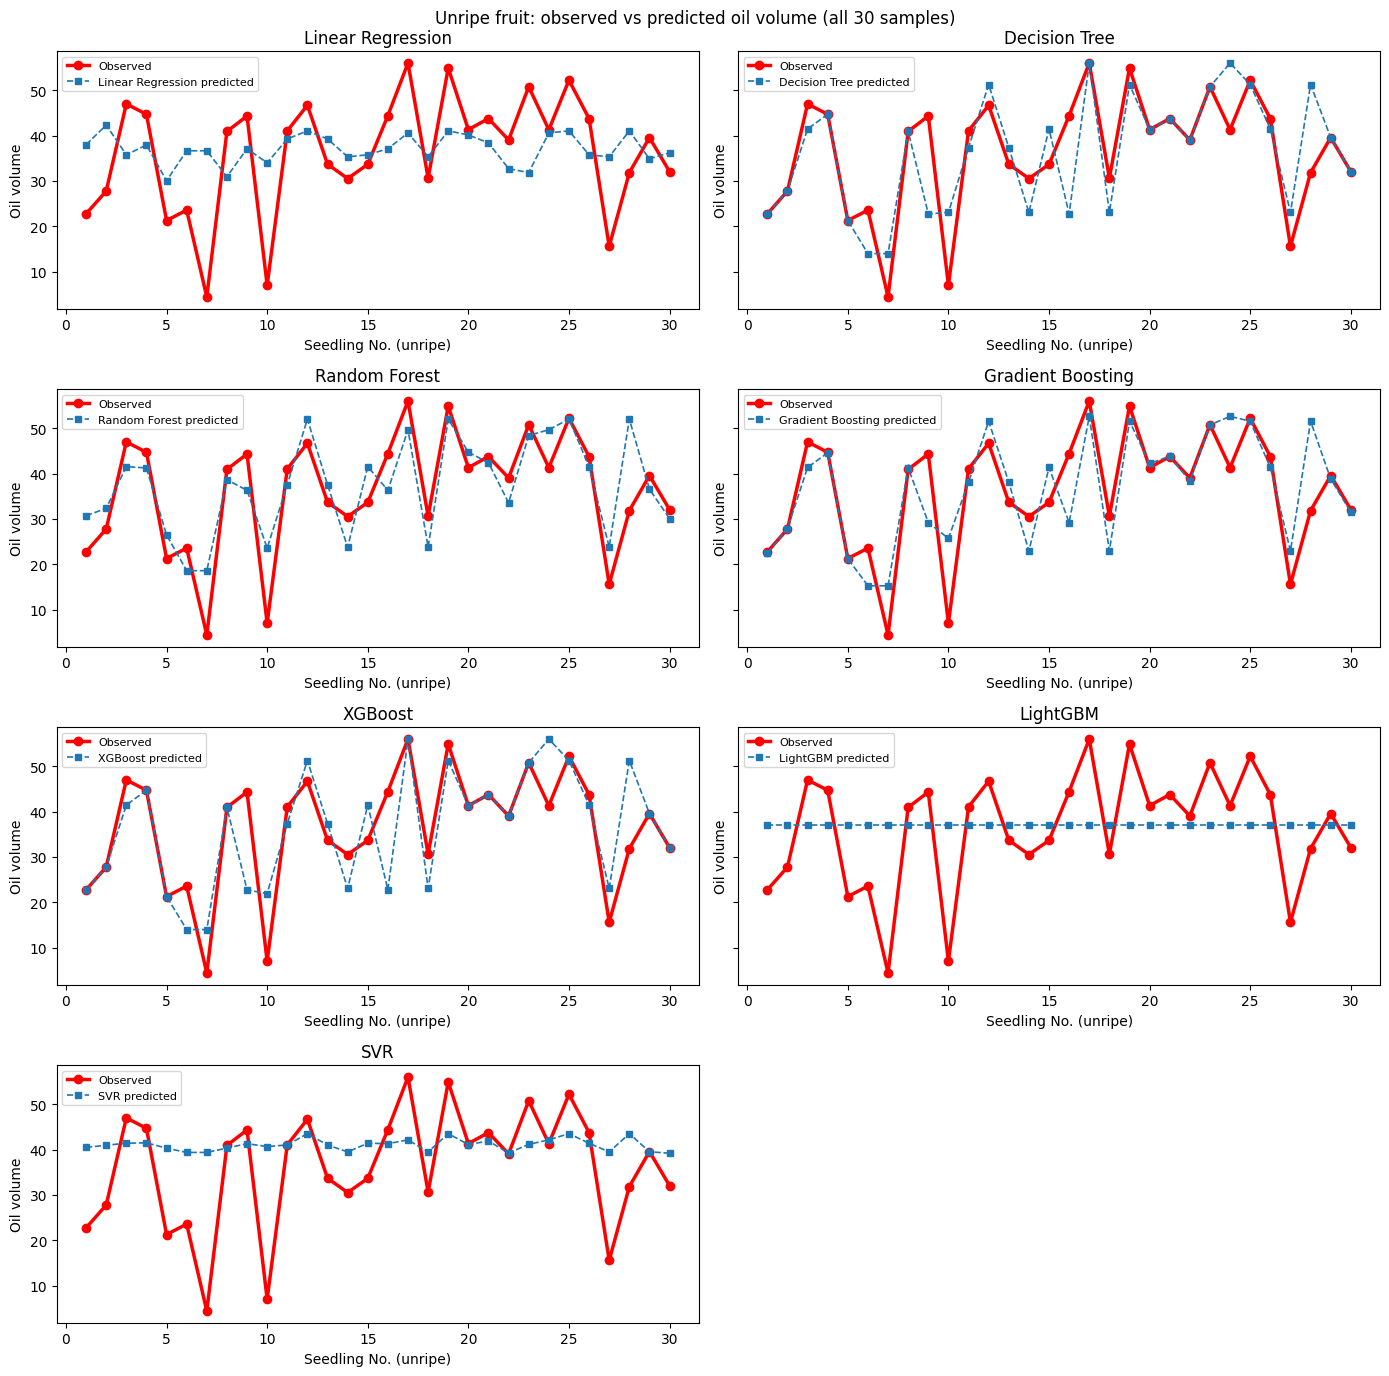

In [ ]:
y_unripe = unripe["Oil Volume"].to_numpy()
sample_ids_u = unripe["No."].to_numpy()

fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharey=True)
for ax, (name, y_pred) in zip(axes.ravel(), pred_unripe.items()):
    ax.plot(sample_ids_u, y_unripe, "o-", color="red", linewidth=2.5, label="Observed")
    ax.plot(sample_ids_u, y_pred, "--s", linewidth=1.2, markersize=4, label=f"{name} predicted")
    ax.set_title(name)
    ax.set_xlabel("Seedling No. (unripe)")
    ax.set_ylabel("Oil volume")
    ax.legend(fontsize=8)
axes.ravel()[-1].axis("off")
fig.suptitle("Unripe fruit: observed vs predicted oil volume (all 30 samples)")
fig.tight_layout()
plt.show()

## Export results / 結果のエクスポート

Write the reproduced metrics and the per-sample predictions to CSV files under `/content` so they can be downloaded from the Colab file browser. Expected: two file paths printed with their row counts.

In [ ]:
out_dir = Path("/content")
metrics_path = out_dir / "table4_reproduced_metrics.csv"
pred_path = out_dir / "oil_volume_predictions.csv"

metrics = pd.concat([results_semi.assign(ripeness="Semi-Ripe"),
                     results_unripe.assign(ripeness="Unripe")])
metrics.to_csv(metrics_path, index=False)

pred_df = pd.DataFrame({"No.": sample_ids})
for name, yp in pred_semi.items():
    pred_df[f"semi_{name}"] = yp
for name, yp in pred_unripe.items():
    pred_df[f"unripe_{name}"] = yp
pred_df.to_csv(pred_path, index=False)

print(metrics_path, metrics.shape)
print(pred_path, pred_df.shape)

/content/table4_reproduced_metrics.csv (14, 5)
/content/oil_volume_predictions.csv (30, 15)


## Interpretation and limitations / 解釈と限界

**What this reproduction shows (observed on Colab CPU, scikit-learn 1.6.1 / xgboost 3.4.1 / lightgbm 4.6.0):** re-running the authors' pipeline on the published figshare v3 data reproduces the structure of Table 4 — tree and boosting models fit far better than Linear Regression, SVR or LightGBM (which cannot split on 24 integer-feature samples and reduces to the global mean). **Reproduction fidelity:** for semi-ripe fruit all seven models match the printed Table 4 with |ΔMSE| ≤ 2.50 (five models within 0.03). For unripe fruit the deterministic models match (Linear Regression Δ 0.03, Gradient Boosting Δ 2.15, LightGBM Δ 0.02, SVR Δ 0.01), while Decision Tree (Δ 30.6), XGBoost (Δ 30.4) and Random Forest (Δ 10.7) deviate: `DecisionTreeRegressor` and `RandomForestRegressor` are instantiated without a fixed `random_state` (exactly as in the author's pinned code) and are therefore run-dependent, and XGBoost 3.4.1 differs from the 2024-era release. The pinned author notebook's own embedded outputs equal the printed Table 4 values, and the provenance cross-check above confirms the input data (max deviation 0.005), so the residual differences are attributable to run-dependent fitting and library versions, not to a data or pipeline mismatch.

**Limitations / 限界:**
- A single 30-sample re-run is **not** a verification of the paper's dataset-level claims; no cross-validation or hyperparameter tuning is performed (none is described in the paper).
- The paper's text does not document the train/test split; the split used here is taken from the pinned author notebook (`train_test_split(test_size=0.2, random_state=42)`), and metrics are computed over all 30 predictions, exactly as the authors did.
- The author repository has no LICENSE file; this notebook is an independent re-implementation guided by the pinned code, and no author code is copied verbatim.
- The oil-content-by-position branch (Tables 2–3) and the authors' auxiliary KNN/Keras models are out of scope.

**References / 参考文献:**
- Shuaib et al. (2024), Acta Agrobotanica 77, https://doi.org/10.5586/aa/196387 (Table 4, Sections 2.8–2.10)
- Dataset: figshare record 28090769 v3, CC BY 4.0 (files 51371681, 51371585)
- Author code: https://github.com/sherif-shuaib/Oil-palm-Thailand @ `aeeae4841e3574d65c1843489e2a0bcf08853661`
